**Dataset creation**

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

# ─────────────────────────────────────────
# STEP 1: LOAD DATA
# ─────────────────────────────────────────
df = pd.read_excel('marketing_campaign_cleaned.xlsx')

# ─────────────────────────────────────────
# STEP 2: CLEAN DATA TYPES
# ─────────────────────────────────────────
df['Year_Birth'] = pd.to_numeric(df['Year_Birth'], errors='coerce')
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['Recency'] = pd.to_numeric(df['Recency'], errors='coerce')
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')

spend_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

for col in spend_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ─────────────────────────────────────────
# STEP 3: HANDLE MISSING VALUES
# ─────────────────────────────────────────
df['Income'].fillna(df['Income'].median(), inplace=True)
df['Recency'].fillna(df['Recency'].median(), inplace=True)

df.dropna(subset=['Year_Birth', 'Dt_Customer'], inplace=True)

# ─────────────────────────────────────────
# STEP 4: FEATURE ENGINEERING
# ─────────────────────────────────────────
current_date = datetime.now()

# Age
df['Age'] = current_date.year - df['Year_Birth']

# Purchases
df['Purchases'] = df[spend_cols].sum(axis=1)

# Membership_days
df['Membership_days'] = (current_date - df['Dt_Customer']).dt.days

# ─────────────────────────────────────────
# STEP 5: SMART MEMBERSHIP (DATA-DRIVEN)
# ─────────────────────────────────────────

q1 = df['Membership_days'].quantile(0.25)
q2 = df['Membership_days'].quantile(0.50)
q3 = df['Membership_days'].quantile(0.75)

def membership_category(days):
    if days <= q1:
        return "New"
    elif days <= q2:
        return "Regular"
    elif days <= q3:
        return "Loyal"
    else:
        return "VIP"

df['Membership'] = df['Membership_days'].apply(membership_category)

# ─────────────────────────────────────────
# STEP 6: NORMALIZATION
# ─────────────────────────────────────────
df['Recency_norm'] = df['Recency'] / df['Recency'].max()
df['Purchases_norm'] = df['Purchases'] / df['Purchases'].max()
df['Income_norm'] = df['Income'] / df['Income'].max()

# ─────────────────────────────────────────
# STEP 7: IMPROVED CHURN LOGIC
# ─────────────────────────────────────────
np.random.seed(42)

churn_prob = (
    0.45 * df['Recency_norm'] +
    0.25 * (1 - df['Purchases_norm']) +
    0.20 * (1 - df['Income_norm']) +
    0.10 * (df['Age'] < 25)
)
churn_prob = churn_prob * 0.8

# Add realistic noise
churn_prob += np.random.normal(0, 0.02, len(df))
churn_prob = np.clip(churn_prob, 0, 1)

df['Churn'] = (np.random.rand(len(df)) < churn_prob).astype(int)
# ─────────────────────────────────────────
# STEP 8: FINAL DATASET
# ─────────────────────────────────────────
df_final = df[['Age', 'Income', 'Purchases', 'Membership','Recency', 'Churn']].copy()
df_final = df_final.dropna().reset_index(drop=True)

# ─────────────────────────────────────────
# STEP 9: VALIDATION (PROPER)
# ─────────────────────────────────────────
print("Dataset Shape:", df_final.shape)

print("\n Sample:")
print(df_final.head())

print("\n Membership Distribution:")
print(df_final['Membership'].value_counts())

print("\nChurn Distribution:")
print(df_final['Churn'].value_counts())

print(f"\n Churn Rate: {df_final['Churn'].mean()*100:.2f}%")

print("\n Full Summary:")
print(df_final.describe(include='all'))

# ─────────────────────────────────────────
# STEP 10: EXPORT
# ─────────────────────────────────────────
df_final.to_csv('customer_churn_final.csv', index=False)

print("\nSaved → customer_churn_final.csv")

/tmp/ipykernel_25360/2347717311.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)
/tmp/ipykernel_25360/2347717311.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

Dataset Shape: (2240, 6)

 Sample:
   Age   Income  Purchases Membership  Recency  Churn
0   69  58138.0       1617        VIP       58      0
1   72  46344.0         27        New       38      0
2   61  71613.0        776    Regular       26      0
3   42  26646.0         53        New       26      0
4   45  58293.0        422        New       94      1

 Membership Distribution:
Membership
Loyal      566
New        560
Regular    560
VIP        554
Name: count, dtype: int64

Churn Distribution:
Churn
0    1153
1    1087
Name: count, dtype: int64

 Churn Rate: 48.53%

 Full Summary:
                Age         Income    Purchases Membership      Recency  \
count   2240.000000    2240.000000  2240.000000       2240  2240.000000   
unique          NaN            NaN          NaN          4          NaN   
top             NaN            NaN          NaN      Loyal          NaN   
freq            NaN            NaN          NaN        566          NaN   
mean      57.194196   52237.9754

**Importing Dependencies**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report,confusion_matrix
import pickle

**Data Loading**



In [3]:
#Loading the dataset to pandas dataframe
df=pd.read_csv("customer_churn_final.csv")

In [4]:
df.shape


(2240, 6)

In [5]:
df.head()

,Age,Income,Purchases,Membership,Recency,Churn
0,69,58138.0,1617,VIP,58,0
1,72,46344.0,27,New,38,0
2,61,71613.0,776,Regular,26,0
3,42,26646.0,53,New,26,0
4,45,58293.0,422,New,94,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         2240 non-null   int64  
 1   Income      2240 non-null   float64
 2   Purchases   2240 non-null   int64  
 3   Membership  2240 non-null   object 
 4   Recency     2240 non-null   int64  
 5   Churn       2240 non-null   int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 105.1+ KB


In [7]:
for col in df.columns:
  print(col,df[col].unique())
  print("-"*50)

Age [ 69  72  61  42  45  59  55  41  52  76  43  50  67  74  39  80  46  77
  44  47  75  57  40  37  63  56  53  83  51  30  58  62  49  48  71  60
  38  78  68  54  66  81  35  64  73  65  70  34 126 133  36  79 127  33
  32  85  82  31  86]
--------------------------------------------------
Income [58138. 46344. 71613. ... 56981. 69245. 52869.]
--------------------------------------------------
Purchases [1617   27  776 ... 1679 1341  843]
--------------------------------------------------
Membership ['VIP' 'New' 'Regular' 'Loyal']
--------------------------------------------------
Recency [58 38 26 94 16 34 32 19 68 11 59 82 53 23 51 20 91 86 41 42 63  0 69 89
  4 96 56 31  8 55 37 76 99  3 88 80 72 24 92 39 29  2 54 57 30 12 18 75
 90  1 25 40  9 87  5 95 48 70 79 45 84 44 43 35 15 17 46 27 74 85 65 13
 83 10 21 61 73 47 36 49 28 64 98 78 77 81 14 52 93 50 60 66 97 62  6 33
 67 22 71  7]
--------------------------------------------------
Churn [0 1]
------------------------------

In [8]:
print(df.isnull().sum())

Age           0
Income        0
Purchases     0
Membership    0
Recency       0
Churn         0
dtype: int64


In [9]:
print(df["Churn"].value_counts())

Churn
0    1153
1    1087
Name: count, dtype: int64


**EXPLORATORY DATA ANLYSIS**

In [10]:
df.describe()

,Age,Income,Purchases,Recency,Churn
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,57.194196,52237.975446,605.798214,49.109375,0.485268
std,11.984069,25037.955891,602.249288,28.962453,0.499895
min,30.000000,1730.000000,5.000000,0.000000,0.000000
25%,49.000000,35538.750000,68.750000,24.000000,0.000000
50%,56.000000,51381.500000,396.000000,49.000000,0.000000
75%,67.000000,68289.750000,1045.500000,74.000000,1.000000
max,133.000000,666666.000000,2525.000000,99.000000,1.000000


**Numerical Features Analysis**

In [11]:
def plot_histogram(df,column_name):
  plt.figure(figsize=(5,3))
  sns.histplot(data=df,x=column_name,kde=True)
  plt.title(f"Distribution of {column_name}")
  col_mean=df[column_name].mean()
  col_median=df[column_name].median()
  plt.axvline(col_mean,color='red',linestyle='dashed',linewidth=1,label='Mean')
  plt.axvline(col_median,color='green',linestyle='dashed',linewidth=1,label='Median')
  plt.legend()
  plt.show()


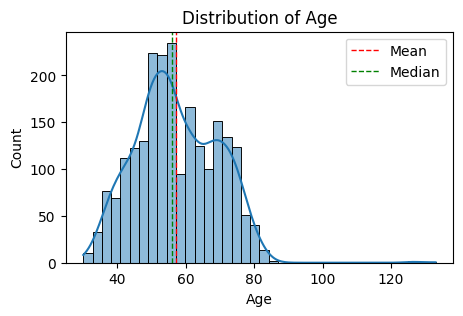

In [12]:
plot_histogram(df,"Age")

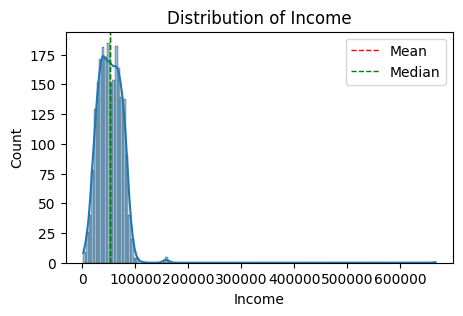

In [13]:
plot_histogram(df,"Income")

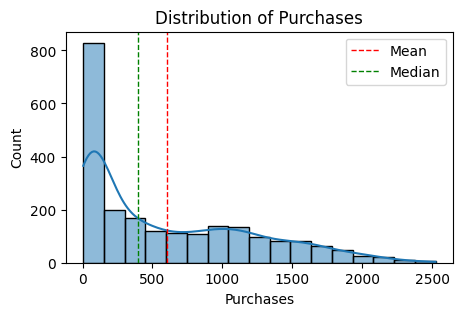

In [14]:
plot_histogram(df,"Purchases")

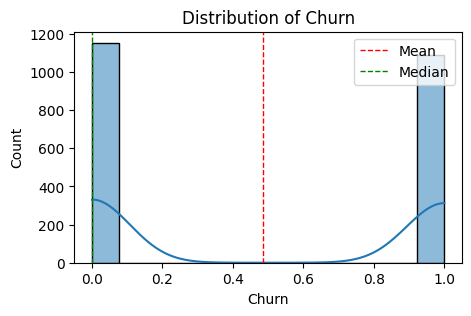

In [15]:
plot_histogram(df,"Churn")

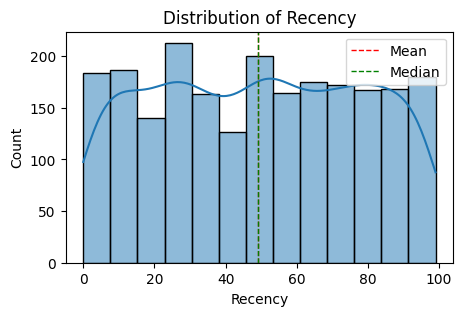

In [16]:
plot_histogram(df,"Recency")

**Box Plot**

In [17]:
def plot_boxplot(df,column_name):
  plt.figure(figsize=(5,3))
  sns.boxplot(x=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel("column_name")
  plt.show()


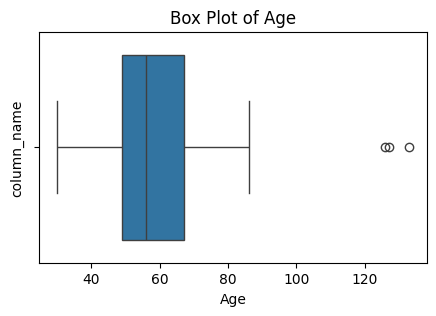

In [18]:
plot_boxplot(df,"Age")

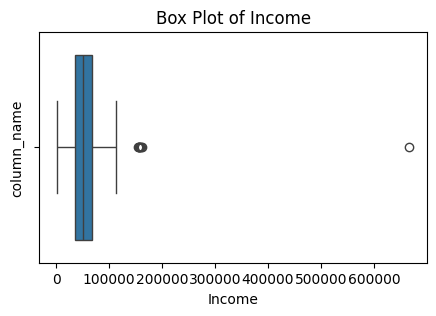

In [19]:
plot_boxplot(df,"Income")

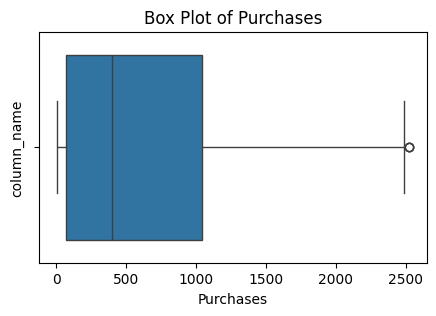

In [20]:
plot_boxplot(df,"Purchases")

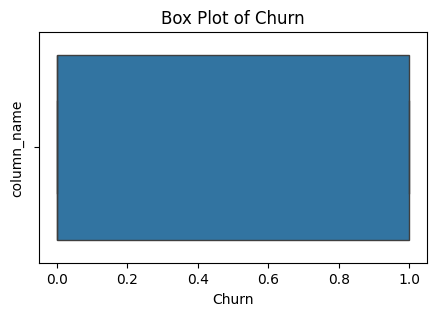

In [21]:
plot_boxplot(df,"Churn")

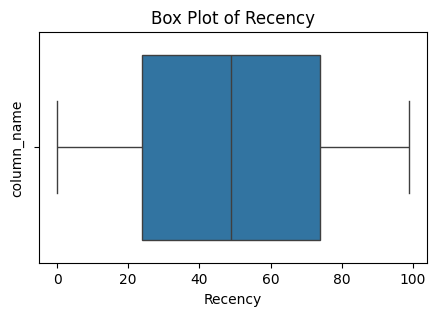

In [22]:
plot_boxplot(df,"Recency")

**Correlation Heatmaps for numerical columns**

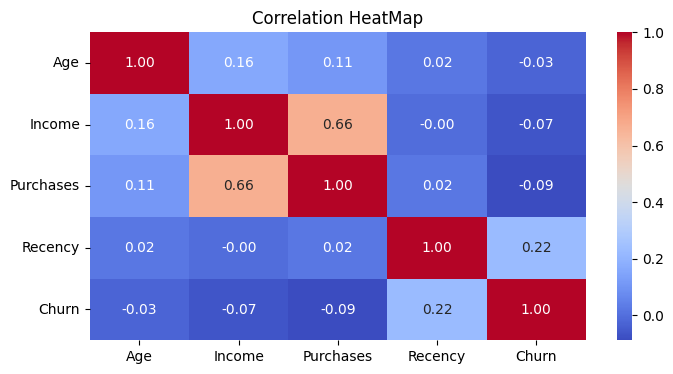

In [23]:
plt.figure(figsize=(8,4))
sns.heatmap(df[["Age","Income","Purchases","Recency","Churn"]].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation HeatMap")
plt.show()

**Count Plot for categorical Columns**

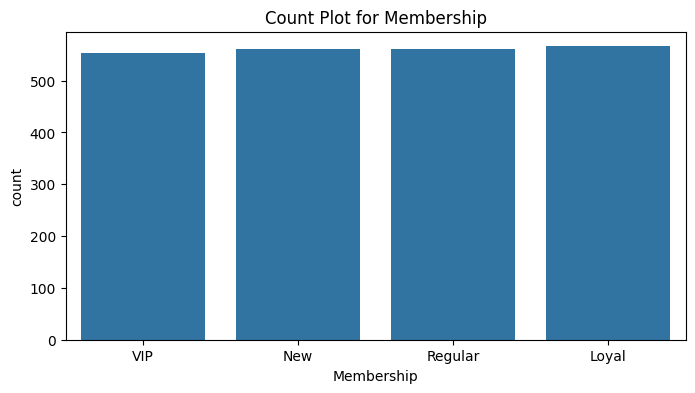

In [24]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="Membership")
plt.title("Count Plot for Membership")
plt.show()


**Data preprocessing**
Label encoding of Membership column

In [25]:
encoders={}
label_encoder=LabelEncoder()
df["Membership"]=label_encoder.fit_transform(df["Membership"])
encoders["Membership"]=label_encoder

In [26]:
print(df["Membership"].value_counts())

Membership
0    566
1    560
2    560
3    554
Name: count, dtype: int64


In [27]:
df.head()

,Age,Income,Purchases,Membership,Recency,Churn
0,69,58138.0,1617,3,58,0
1,72,46344.0,27,1,38,0
2,61,71613.0,776,2,26,0
3,42,26646.0,53,1,26,0
4,45,58293.0,422,1,94,1


**Training and Testing Split**

In [28]:

df_encoded = pd.get_dummies(df_final, columns=['Membership'])

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
feature_columns = X.columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f' Feature matrix X: {X.shape} | Target y: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples (stratified)')

 Feature matrix X: (2240, 8) | Target y: (2240,)
Train: 1792 samples | Test: 448 samples (stratified)


**LOGISTIC REGRESSION**

In [48]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Random forest**

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

**XGBoost**

In [57]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [32]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, lr.predict(X_test)))

print("Random Forest:")
print(classification_report(y_test, rf.predict(X_test)))

print("XG Boost:")
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.62      0.69      0.66       231
           1       0.63      0.55      0.59       217

    accuracy                           0.62       448
   macro avg       0.63      0.62      0.62       448
weighted avg       0.63      0.62      0.62       448

Random Forest:
              precision    recall  f1-score   support

           0       0.58      0.61      0.59       231
           1       0.56      0.52      0.54       217

    accuracy                           0.57       448
   macro avg       0.57      0.57      0.57       448
weighted avg       0.57      0.57      0.57       448

XG Boost:
              precision    recall  f1-score   support

           0       0.60      0.66      0.63       231
           1       0.59      0.53      0.56       217

    accuracy                           0.60       448
   macro avg       0.60      0.59      0.59       448
weighted avg       0.60     

**Hyper parameter tuning**

> LOGISTIC REGRESSION




In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(max_iter=2000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR Score:", grid_lr.best_score_)

Best LR Params: {'C': 0.01, 'solver': 'liblinear'}
Best LR Score: 0.570904265847212




> RANDOM FOREST





In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

Best RF Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best RF Score: 0.5706371105542726




> XG Boost



In [35]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_xgb = RandomizedSearchCV(
    xgb,
    param_dist_xgb,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_train, y_train)

print("Best XGB Params:", random_xgb.best_params_)
print("Best XGB Score:", random_xgb.best_score_)

Best XGB Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best XGB Score: 0.5815052256016042


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:46:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [36]:
from sklearn.metrics import classification_report

# Logistic Regression
best_lr = grid_lr.best_estimator_
print("LR Results:")
print(classification_report(y_test, best_lr.predict(X_test)))

# Random Forest
best_rf = grid_rf.best_estimator_
print("RF Results:")
print(classification_report(y_test, best_rf.predict(X_test)))

# XGBoost
best_xgb = random_xgb.best_estimator_
print("XGB Results:")
print(classification_report(y_test, best_xgb.predict(X_test)))

LR Results:
              precision    recall  f1-score   support

           0       0.64      0.68      0.66       231
           1       0.64      0.59      0.61       217

    accuracy                           0.64       448
   macro avg       0.64      0.64      0.64       448
weighted avg       0.64      0.64      0.64       448

RF Results:
              precision    recall  f1-score   support

           0       0.62      0.66      0.64       231
           1       0.61      0.57      0.59       217

    accuracy                           0.61       448
   macro avg       0.61      0.61      0.61       448
weighted avg       0.61      0.61      0.61       448

XGB Results:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62       231
           1       0.60      0.60      0.60       217

    accuracy                           0.61       448
   macro avg       0.61      0.61      0.61       448
weighted avg       0.61      0.61    

**PREDICTION**

In [37]:
model = best_lr

In [38]:
new_customer = pd.DataFrame({
    'Age': [30],
    'Income': [40000],
    'Purchases': [250],
    'Recency': [70],
    'Membership_New': [0],
    'Membership_Regular': [1],
    'Membership_Loyal': [0],
    'Membership_VIP': [0]
})

# Align columns
new_customer = new_customer.reindex(columns=feature_columns, fill_value=0)

prediction = model.predict(new_customer)
print("Churn:", prediction[0])

Churn: 1


**RULE BASED SYSTEM**

In [39]:
def rule_based_churn(row):
    age = row['Age']
    income = row['Income']
    purchases = row['Purchases']
    membership = row['Membership']

    # Rule 1 — Very low purchases + New member → churn
    if purchases < 100 and membership == 'New':
        return 1, "Rule 1: Low purchases + New"

    # Rule 2 — High purchases + VIP/Loyal → retain
    if purchases > 1500 and membership in ['VIP', 'Loyal']:
        return 0, "Rule 2: High purchases + premium member"

    # Rule 3 — Low income + low activity → churn
    if income < 20000 and purchases < 300:
        return 1, "Rule 3: Low income + low activity"

    # Rule 4 — Senior high-value customer → retain
    if age >= 65 and income > 60000 and purchases > 500:
        return 0, "Rule 4: Senior high-value"

    # Rule 5 — Active mid-tier customer → retain
    if purchases > 800 and membership in ['Regular', 'Loyal', 'VIP']:
        return 0, "Rule 5: Active member"

    # Rule 6 — Very low purchases → churn
    if purchases < 50:
        return 1, "Rule 6: Very low purchases"

    if purchases > 400:
      return 0, "Default: Moderate activity"
    elif income > 40000:
      return 0, "Default: Stable income"
    else:
      return 1, "Default: Low engagement"

In [40]:
# Copy test data
test_df = X_test.copy()

# Add back Membership column from original dataset
test_df['Membership'] = df_final.loc[X_test.index, 'Membership']

# Add true labels
test_df['Churn_True'] = y_test.values

In [41]:
results = test_df.apply(rule_based_churn, axis=1)

# Extract prediction + reason
test_df['Churn_Rule_Pred'] = [r[0] for r in results]
test_df['Rule_Reason'] = [r[1] for r in results]

In [42]:
rule_acc  = accuracy_score(y_test, test_df['Churn_Rule_Pred'])
rule_prec = precision_score(y_test, test_df['Churn_Rule_Pred'])
rule_rec  = recall_score(y_test, test_df['Churn_Rule_Pred'])
rule_f1   = f1_score(y_test, test_df['Churn_Rule_Pred'])

print("Rule-Based System Performance:")
print(f"Accuracy  : {rule_acc:.4f}")
print(f"Precision : {rule_prec:.4f}")
print(f"Recall    : {rule_rec:.4f}")
print(f"F1 Score  : {rule_f1:.4f}")

Rule-Based System Performance:
Accuracy  : 0.5647
Precision : 0.5753
Recall    : 0.3871
F1 Score  : 0.4628


In [43]:
print("\nRule Trigger Breakdown:")
print(test_df['Rule_Reason'].value_counts())


Rule Trigger Breakdown:
Rule_Reason
Default: Moderate activity                 94
Rule 5: Active member                      64
Default: Stable income                     55
Default: Low engagement                    49
Rule 4: Senior high-value                  49
Rule 1: Low purchases + New                41
Rule 2: High purchases + premium member    40
Rule 6: Very low purchases                 36
Rule 3: Low income + low activity          20
Name: count, dtype: int64


In [44]:
display_cols = [
    'Age', 'Income', 'Purchases', 'Membership',
    'Churn_True', 'Churn_Rule_Pred', 'Rule_Reason'
]

print("\nSample Predictions:")
print(test_df[display_cols].head(10))


Sample Predictions:
      Age   Income  Purchases Membership  Churn_True  Churn_Rule_Pred  \
419    55  49505.0        751      Loyal           1                0   
1747   80  66835.0       1033    Regular           0                0   
1980   42  24570.0        193      Loyal           1                1   
2046   67  53154.0        158        New           0                0   
449    73  55707.0        428    Regular           0                0   
1666   59  63246.0        772    Regular           0                0   
980    66  46779.0         23    Regular           1                1   
1376   51  56243.0        396    Regular           0                0   
255    52  30899.0         33        VIP           1                1   
244    68  61074.0       1102        VIP           0                0   

                     Rule_Reason  
419   Default: Moderate activity  
1747   Rule 4: Senior high-value  
1980     Default: Low engagement  
2046      Default: Stable income  


**MODEL SUMMARY**

> LOGISTIC REGRESSION



AUC-ROC: 0.6664073253935006


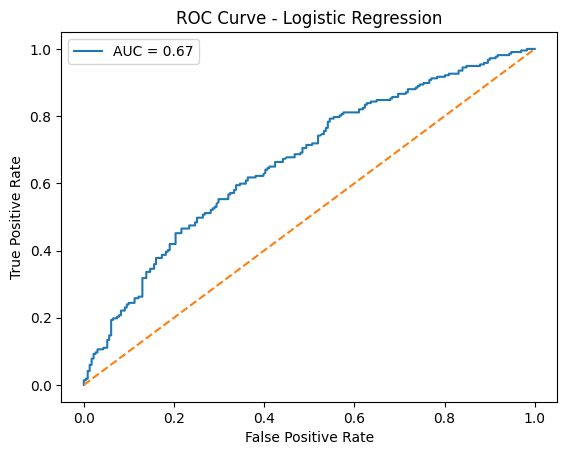

In [49]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probabilities
y_prob = lr.predict_proba(X_test)[:, 1]

# AUC score
auc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [50]:
from sklearn.metrics import confusion_matrix

y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[160  71]
 [ 97 120]]


In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.625
Precision: 0.6282722513089005
Recall   : 0.5529953917050692
F1 Score : 0.5882352941176471




> RANDOM FOREST



AUC-ROC: 0.5751092225746604


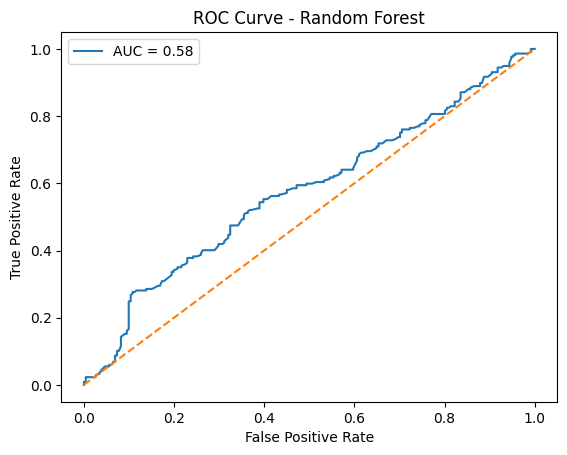

In [53]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

# AUC score
auc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [54]:
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[141  90]
 [ 99 118]]


In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.578125
Precision: 0.5673076923076923
Recall   : 0.543778801843318
F1 Score : 0.5552941176470588




> XG BOOST


AUC-ROC: 0.6398248448939694


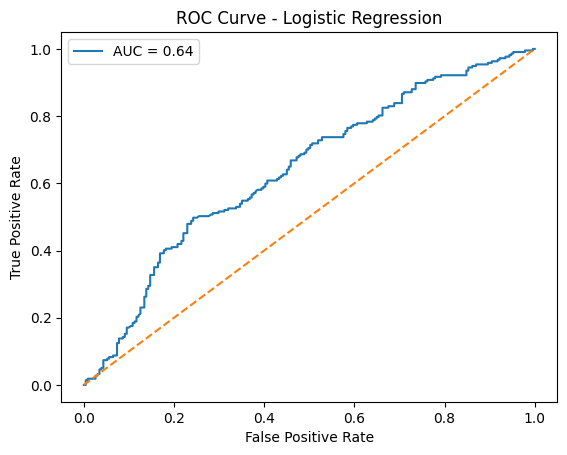

In [58]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probabilities
y_prob = xgb.predict_proba(X_test)[:, 1]

# AUC score
auc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [59]:
from sklearn.metrics import confusion_matrix

y_pred = xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[153  78]
 [103 114]]


In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.5959821428571429
Precision: 0.59375
Recall   : 0.5253456221198156
F1 Score : 0.5574572127139364
